# Q5 - Gaussian Filtering


## 1 - Import Required Libraries


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D


## 2 - Set Input and Output Paths

In [ ]:
img_path = Path("../data/raw/woman_window.jpg")   # change if needed
out_dir = Path("../results/q05")
out_dir.mkdir(parents=True, exist_ok=True)

print("Input path:", img_path.resolve())
print("Output folder:", out_dir.resolve())


Input path: D:\MSc in AI\1YQ3\CV\Assignment_1\data\raw\woman_window.jpg
Output folder: D:\MSc in AI\1YQ3\CV\Assignment_1\results\q05


## 3 - Load Grayscale Image

In [3]:
img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")

print("Image loaded successfully")
print("Shape:", img.shape)
print("Data type:", img.dtype)


Image loaded successfully
Shape: (5867, 4693)
Data type: uint8


## 4 - Display Original Image

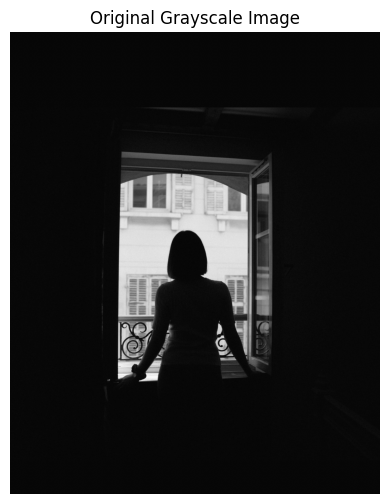

In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


## 5 - Define Gaussian Kernel Function

In [5]:
def gaussian_kernel(size, sigma):
    """
    Generate a normalized Gaussian kernel using NumPy.
    """
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()

    return kernel


## 6 - Compute Normalized 5x5 Gaussian Kernel

In [6]:
kernel_5x5 = gaussian_kernel(5, 2)

print("Normalized 5x5 Gaussian Kernel (sigma = 2):")
print(kernel_5x5)
print("Kernel sum:", kernel_5x5.sum())


Normalized 5x5 Gaussian Kernel (sigma = 2):
[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]
Kernel sum: 1.0


## 7 - Visualize 5x5 Kernel

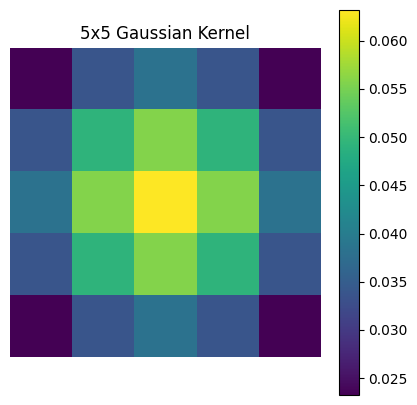

In [7]:
plt.figure(figsize=(5, 5))
plt.imshow(kernel_5x5, cmap="viridis")
plt.title("5x5 Gaussian Kernel")
plt.colorbar()
plt.axis("off")
plt.show()


## 8 - Compute 51x51 Gaussian Kernel

In [8]:
kernel_51x51 = gaussian_kernel(51, 2)

x = np.arange(-(51 // 2), 51 // 2 + 1)
y = np.arange(-(51 // 2), 51 // 2 + 1)
xx, yy = np.meshgrid(x, y)


## 9 - Plot 3D Gaussian Surface

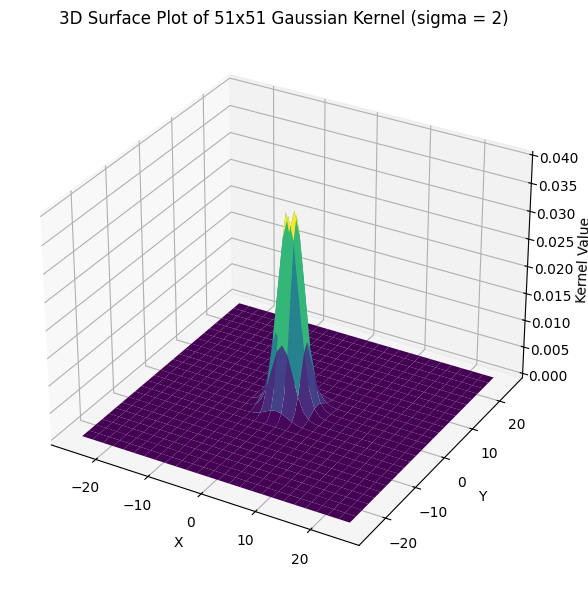

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xx, yy, kernel_51x51, cmap="viridis")

ax.set_title("3D Surface Plot of 51x51 Gaussian Kernel (sigma = 2)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Kernel Value")

plt.tight_layout()
plt.show()


## 10 - Apply Manual Gaussian Smoothing

In [10]:
smoothed_manual = cv2.filter2D(img, -1, kernel_5x5)
print("Manual Gaussian smoothing completed.")


Manual Gaussian smoothing completed.


## 11 - Apply OpenCV GaussianBlur

In [11]:
smoothed_cv = cv2.GaussianBlur(img, (5, 5), sigmaX=2, sigmaY=2)
print("OpenCV GaussianBlur completed.")


OpenCV GaussianBlur completed.


## 12 - Display Smoothing Results

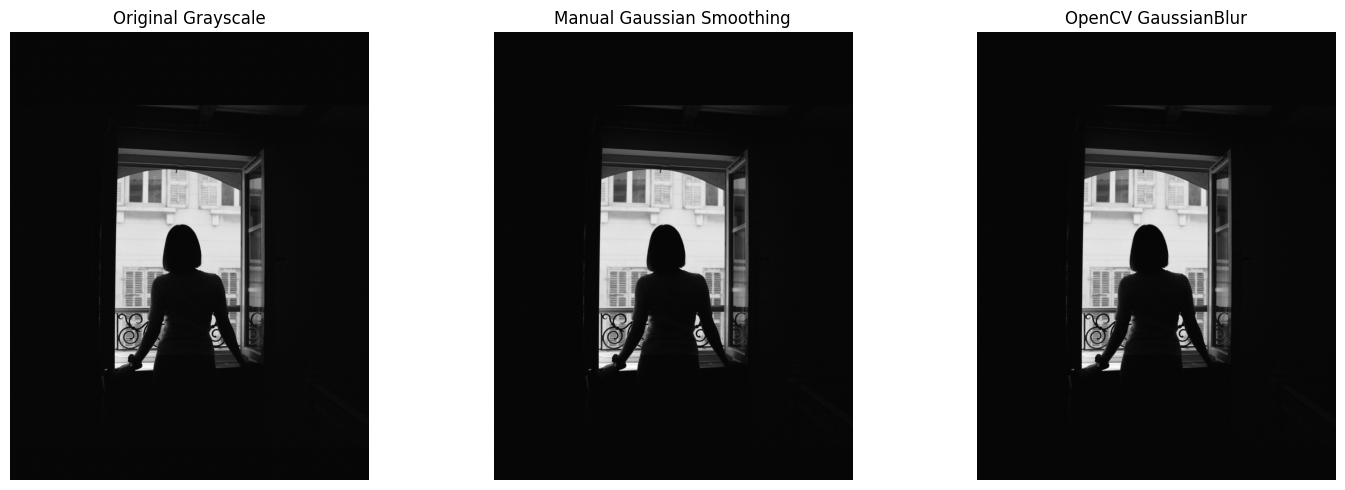

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(smoothed_manual, cmap="gray")
plt.title("Manual Gaussian Smoothing")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(smoothed_cv, cmap="gray")
plt.title("OpenCV GaussianBlur")
plt.axis("off")

plt.tight_layout()
plt.show()


## 13 - Save Output Images

In [13]:
cv2.imwrite(str(out_dir / "q05_original_gray.png"), img)
cv2.imwrite(str(out_dir / "q05_manual_gaussian.png"), smoothed_manual)
cv2.imwrite(str(out_dir / "q05_opencv_gaussian.png"), smoothed_cv)

print(f"Saved original image to: {out_dir / 'q05_original_gray.png'}")
print(f"Saved manual Gaussian result to: {out_dir / 'q05_manual_gaussian.png'}")
print(f"Saved OpenCV Gaussian result to: {out_dir / 'q05_opencv_gaussian.png'}")


Saved original image to: ..\results\q05\q05_original_gray.png
Saved manual Gaussian result to: ..\results\q05\q05_manual_gaussian.png
Saved OpenCV Gaussian result to: ..\results\q05\q05_opencv_gaussian.png


## 14 - Compare Manual and OpenCV Results

In [14]:
difference = np.abs(smoothed_manual.astype(np.int16) - smoothed_cv.astype(np.int16))

print("Maximum pixel difference:", difference.max())
print("Mean pixel difference:", difference.mean())


Maximum pixel difference: 1
Mean pixel difference: 0.0008866546758422393


## 15 - Display Absolute Difference Image

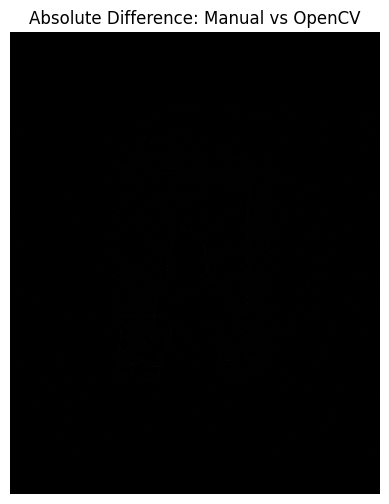

In [15]:
plt.figure(figsize=(6, 6))
plt.imshow(difference, cmap="gray")
plt.title("Absolute Difference: Manual vs OpenCV")
plt.axis("off")
plt.show()


## Interpretation and Discussion

A normalized 5x5 Gaussian kernel with sigma = 2 was computed manually using NumPy.  
A larger 51x51 kernel was also generated and visualized as a 3D surface plot, showing the characteristic bell-shaped Gaussian distribution.

Gaussian smoothing was then applied to the grayscale image in two ways:
1. using the manually computed kernel with `cv2.filter2D()`
2. using OpenCV’s built-in `cv2.GaussianBlur()` function

Both results appear visually very similar. The smoothing reduces noise and softens fine details by averaging neighboring pixel values with Gaussian weights. The difference image shows whether any small implementation or border-handling differences exist between the two methods.